# BrailleLens — Fingertip YOLO26n (Google Colab **T4 GPU**)

Single-class `fingertip` detector for tip-only phone / future smart-glasses views.

## Before you run

1. On PC (already done if you ran prepare): folder `finger_cell_track/datasets/fingertip_yolo26/`
2. Zip it → upload zip to **Google Drive** (easiest for ~400MB)
3. In Colab: **Runtime → Change runtime type → T4 GPU**
4. Run all cells below

In [8]:
# 1) Confirm T4 / CUDA
import torch
assert torch.cuda.is_available(), 'Enable GPU: Runtime → Change runtime type → T4 GPU'
print('torch', torch.__version__)
print('GPU:', torch.cuda.get_device_name(0))

torch 2.11.0+cu128
GPU: Tesla T4


In [9]:
# Mount Drive — accepts FOLDER or .zip
from google.colab import drive
from pathlib import Path
import zipfile
import shutil

drive.mount('/content/drive')

DRIVE_CANDIDATES = [
    Path('/content/drive/MyDrive/BrailleLens/fingertip_yolo26'),
    Path('/content/drive/MyDrive/fingertip_yolo26'),
    Path('/content/drive/MyDrive/BrailleLens/fingertip_yolo26.zip'),
    Path('/content/drive/MyDrive/fingertip_yolo26.zip'),
]

bl = Path('/content/drive/MyDrive/BrailleLens')
print('BrailleLens exists:', bl.exists())
if bl.exists():
    for p in sorted(bl.iterdir()):
        kind = '(dir)' if p.is_dir() else f'({p.stat().st_size/1e6:.1f} MB)'
        print(' -', p.name, kind)

src = next((p for p in DRIVE_CANDIDATES if p.exists()), None)
assert src is not None, (
    'Dataset not found. Put folder fingertip_yolo26/ OR fingertip_yolo26.zip '
    'under MyDrive/BrailleLens/ then re-run.'
)
print('Using:', src)

DATA_DIR = Path('/content/fingertip_yolo26')
if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

if src.suffix.lower() == '.zip':
    with zipfile.ZipFile(src, 'r') as z:
        z.extractall('/content')
    nested = Path('/content/fingertip_yolo26')
    if (nested / 'data.yaml').exists():
        DATA_DIR = nested
    else:
        hits = [h for h in Path('/content').rglob('data.yaml')
                if (h.parent / 'images').exists() or 'fingertip' in str(h).lower()]
        assert hits, 'data.yaml not found after unzip'
        DATA_DIR = hits[0].parent
else:
    shutil.copytree(src, DATA_DIR)

DATA_YAML = DATA_DIR / 'data.yaml'
assert DATA_YAML.exists(), f'No data.yaml in {DATA_DIR}'
print('DATA_DIR =', DATA_DIR)
print(DATA_YAML.read_text()[:500])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BrailleLens exists: True
 - fingertip_yolo26 (dir)
Using: /content/drive/MyDrive/BrailleLens/fingertip_yolo26
DATA_DIR = /content/fingertip_yolo26
# BrailleLens fingertip detector (single class)
path: C:/Users/ADMIN/Documents/Sem 5 my aca/CS3501 Data Science and Engineering Project/BrailleLens/finger_cell_track/datasets/fingertip_yolo26
train: images/train
val: images/val
test: images/test

nc: 1
names:
  0: fingertip



In [10]:
# 3) Rewrite path: in data.yaml to this Colab folder
lines = []
for line in DATA_YAML.read_text().splitlines():
    if line.startswith('path:'):
        lines.append(f'path: {DATA_DIR.resolve().as_posix()}')
    else:
        lines.append(line)
DATA_YAML.write_text('\n'.join(lines) + '\n')
print(DATA_YAML.read_text())

# BrailleLens fingertip detector (single class)
path: /content/fingertip_yolo26
train: images/train
val: images/val
test: images/test

nc: 1
names:
  0: fingertip



In [11]:
# 4) Install Ultralytics
%pip install -q ultralytics
from ultralytics import YOLO
import ultralytics
print('ultralytics', ultralytics.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics 8.4.115


In [12]:
# 5) Train YOLO26n on T4
EPOCHS = 50
IMGSZ = 640
BATCH = 16          # if OOM: set to 8
MODEL = 'yolo26n.pt'
PROJECT = '/content/runs/fingertip'
NAME = 'yolo26n_tip'

model = YOLO(MODEL)
results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=0,
    project=PROJECT,
    name=NAME,
    exist_ok=True,
    patience=15,
    plots=True,
)
print('training finished')

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fingertip_yolo26/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_tip, nbs=64, nms=F

best: /content/runs/fingertip/yolo26n_tip/weights/best.pt True
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 495.5±283.4 MB/s, size: 18.6 KB)
val: Scanning /content/fingertip_yolo26/labels/val.cache... 757 images, 203 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 757/757 158.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 3.5it/s 13.8s
                   all        757        894      0.938      0.871      0.943      0.703
Speed: 3.2ms preprocess, 5.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val


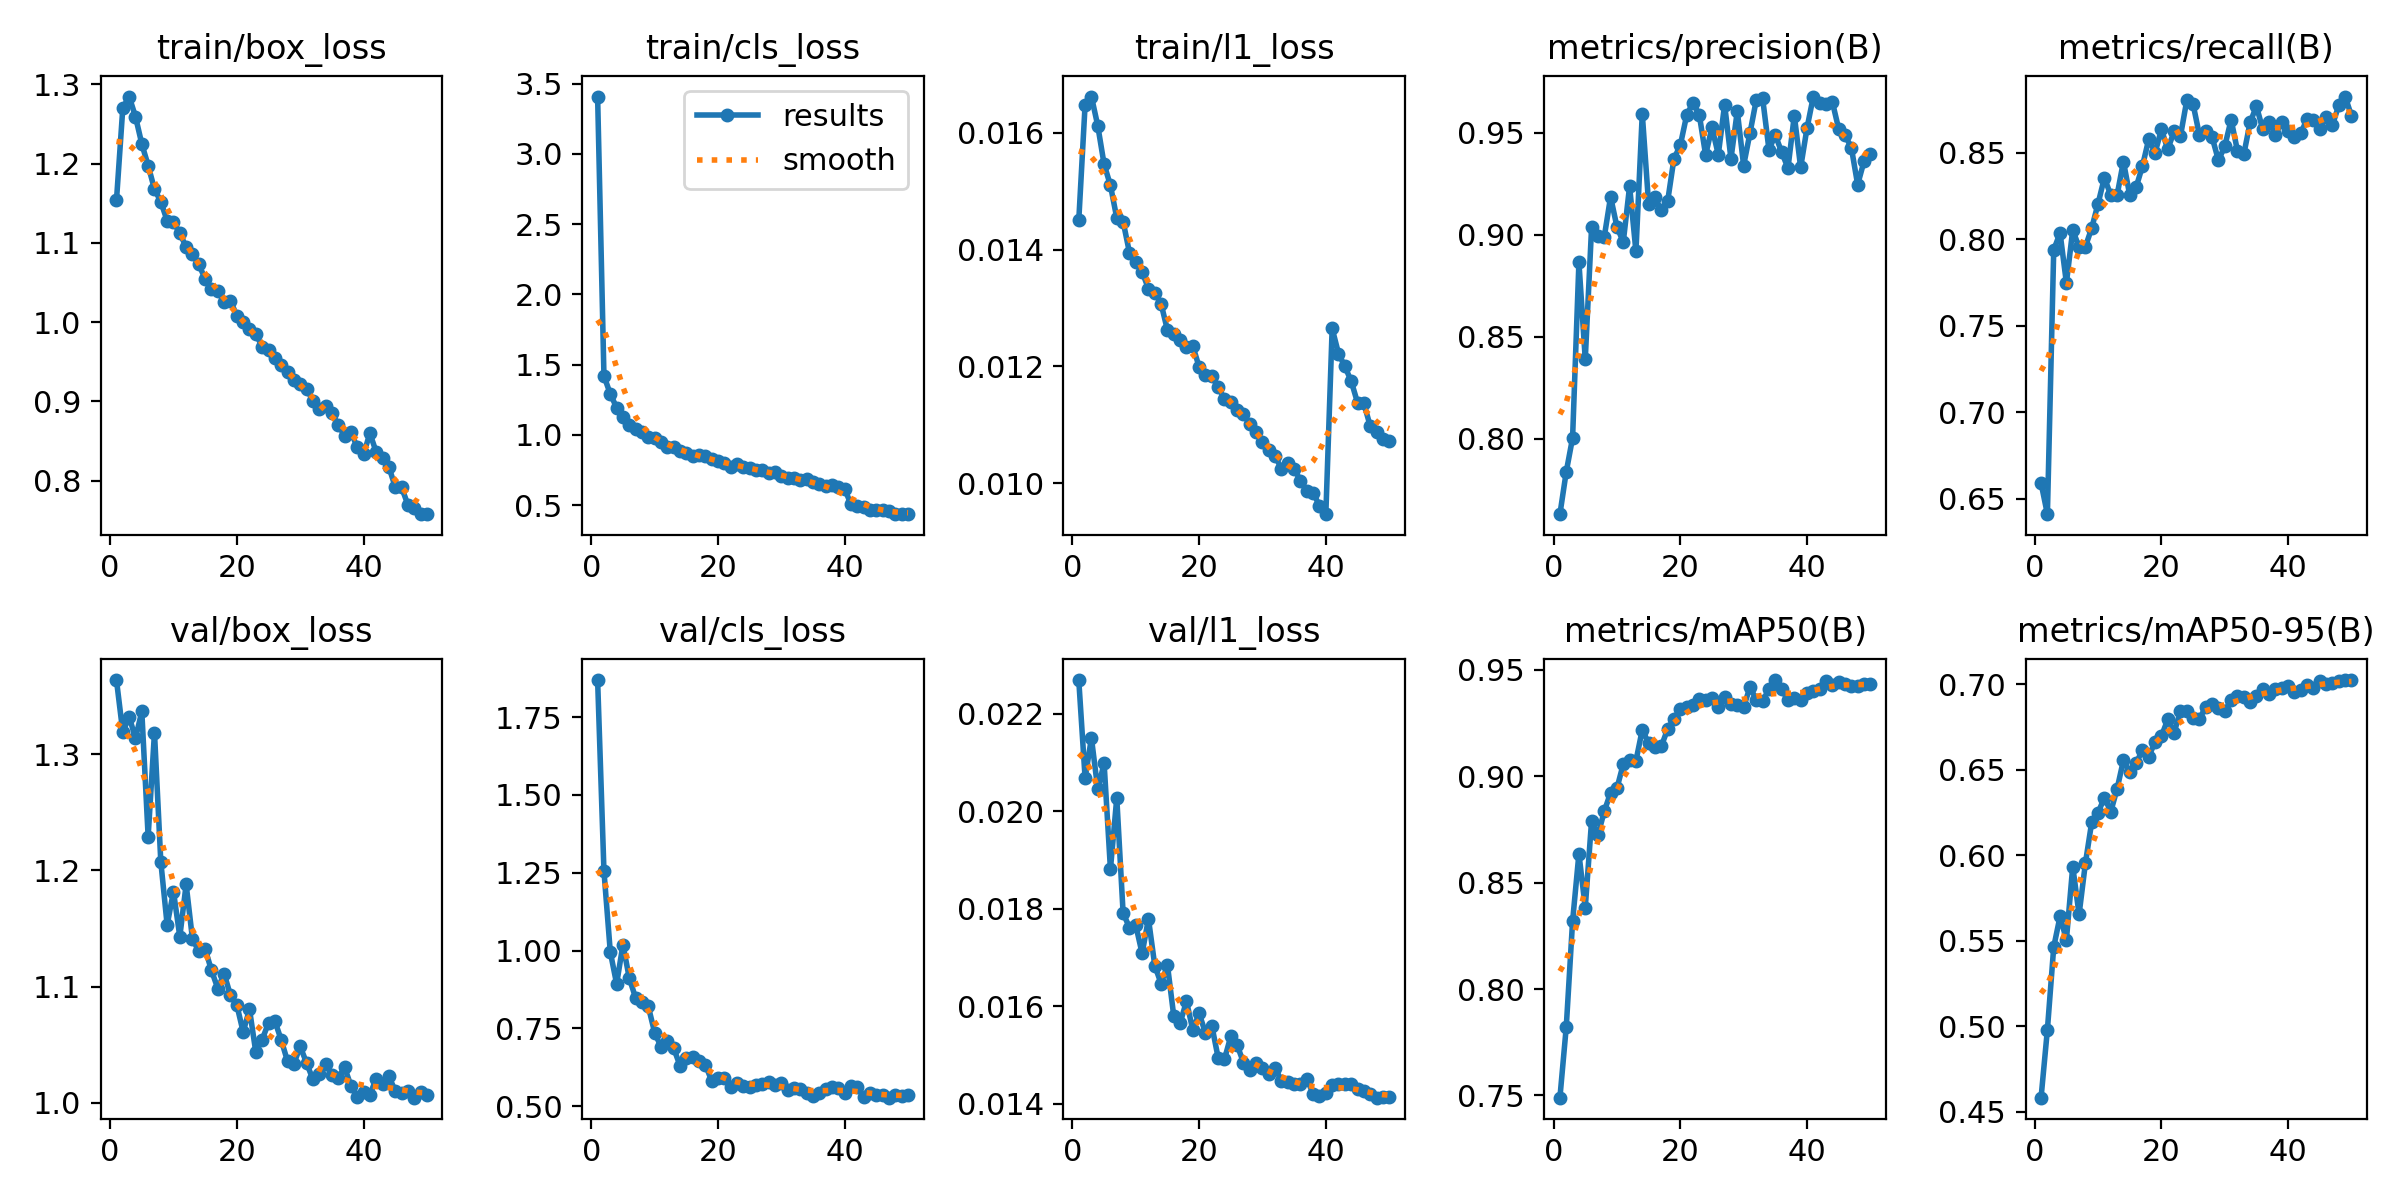

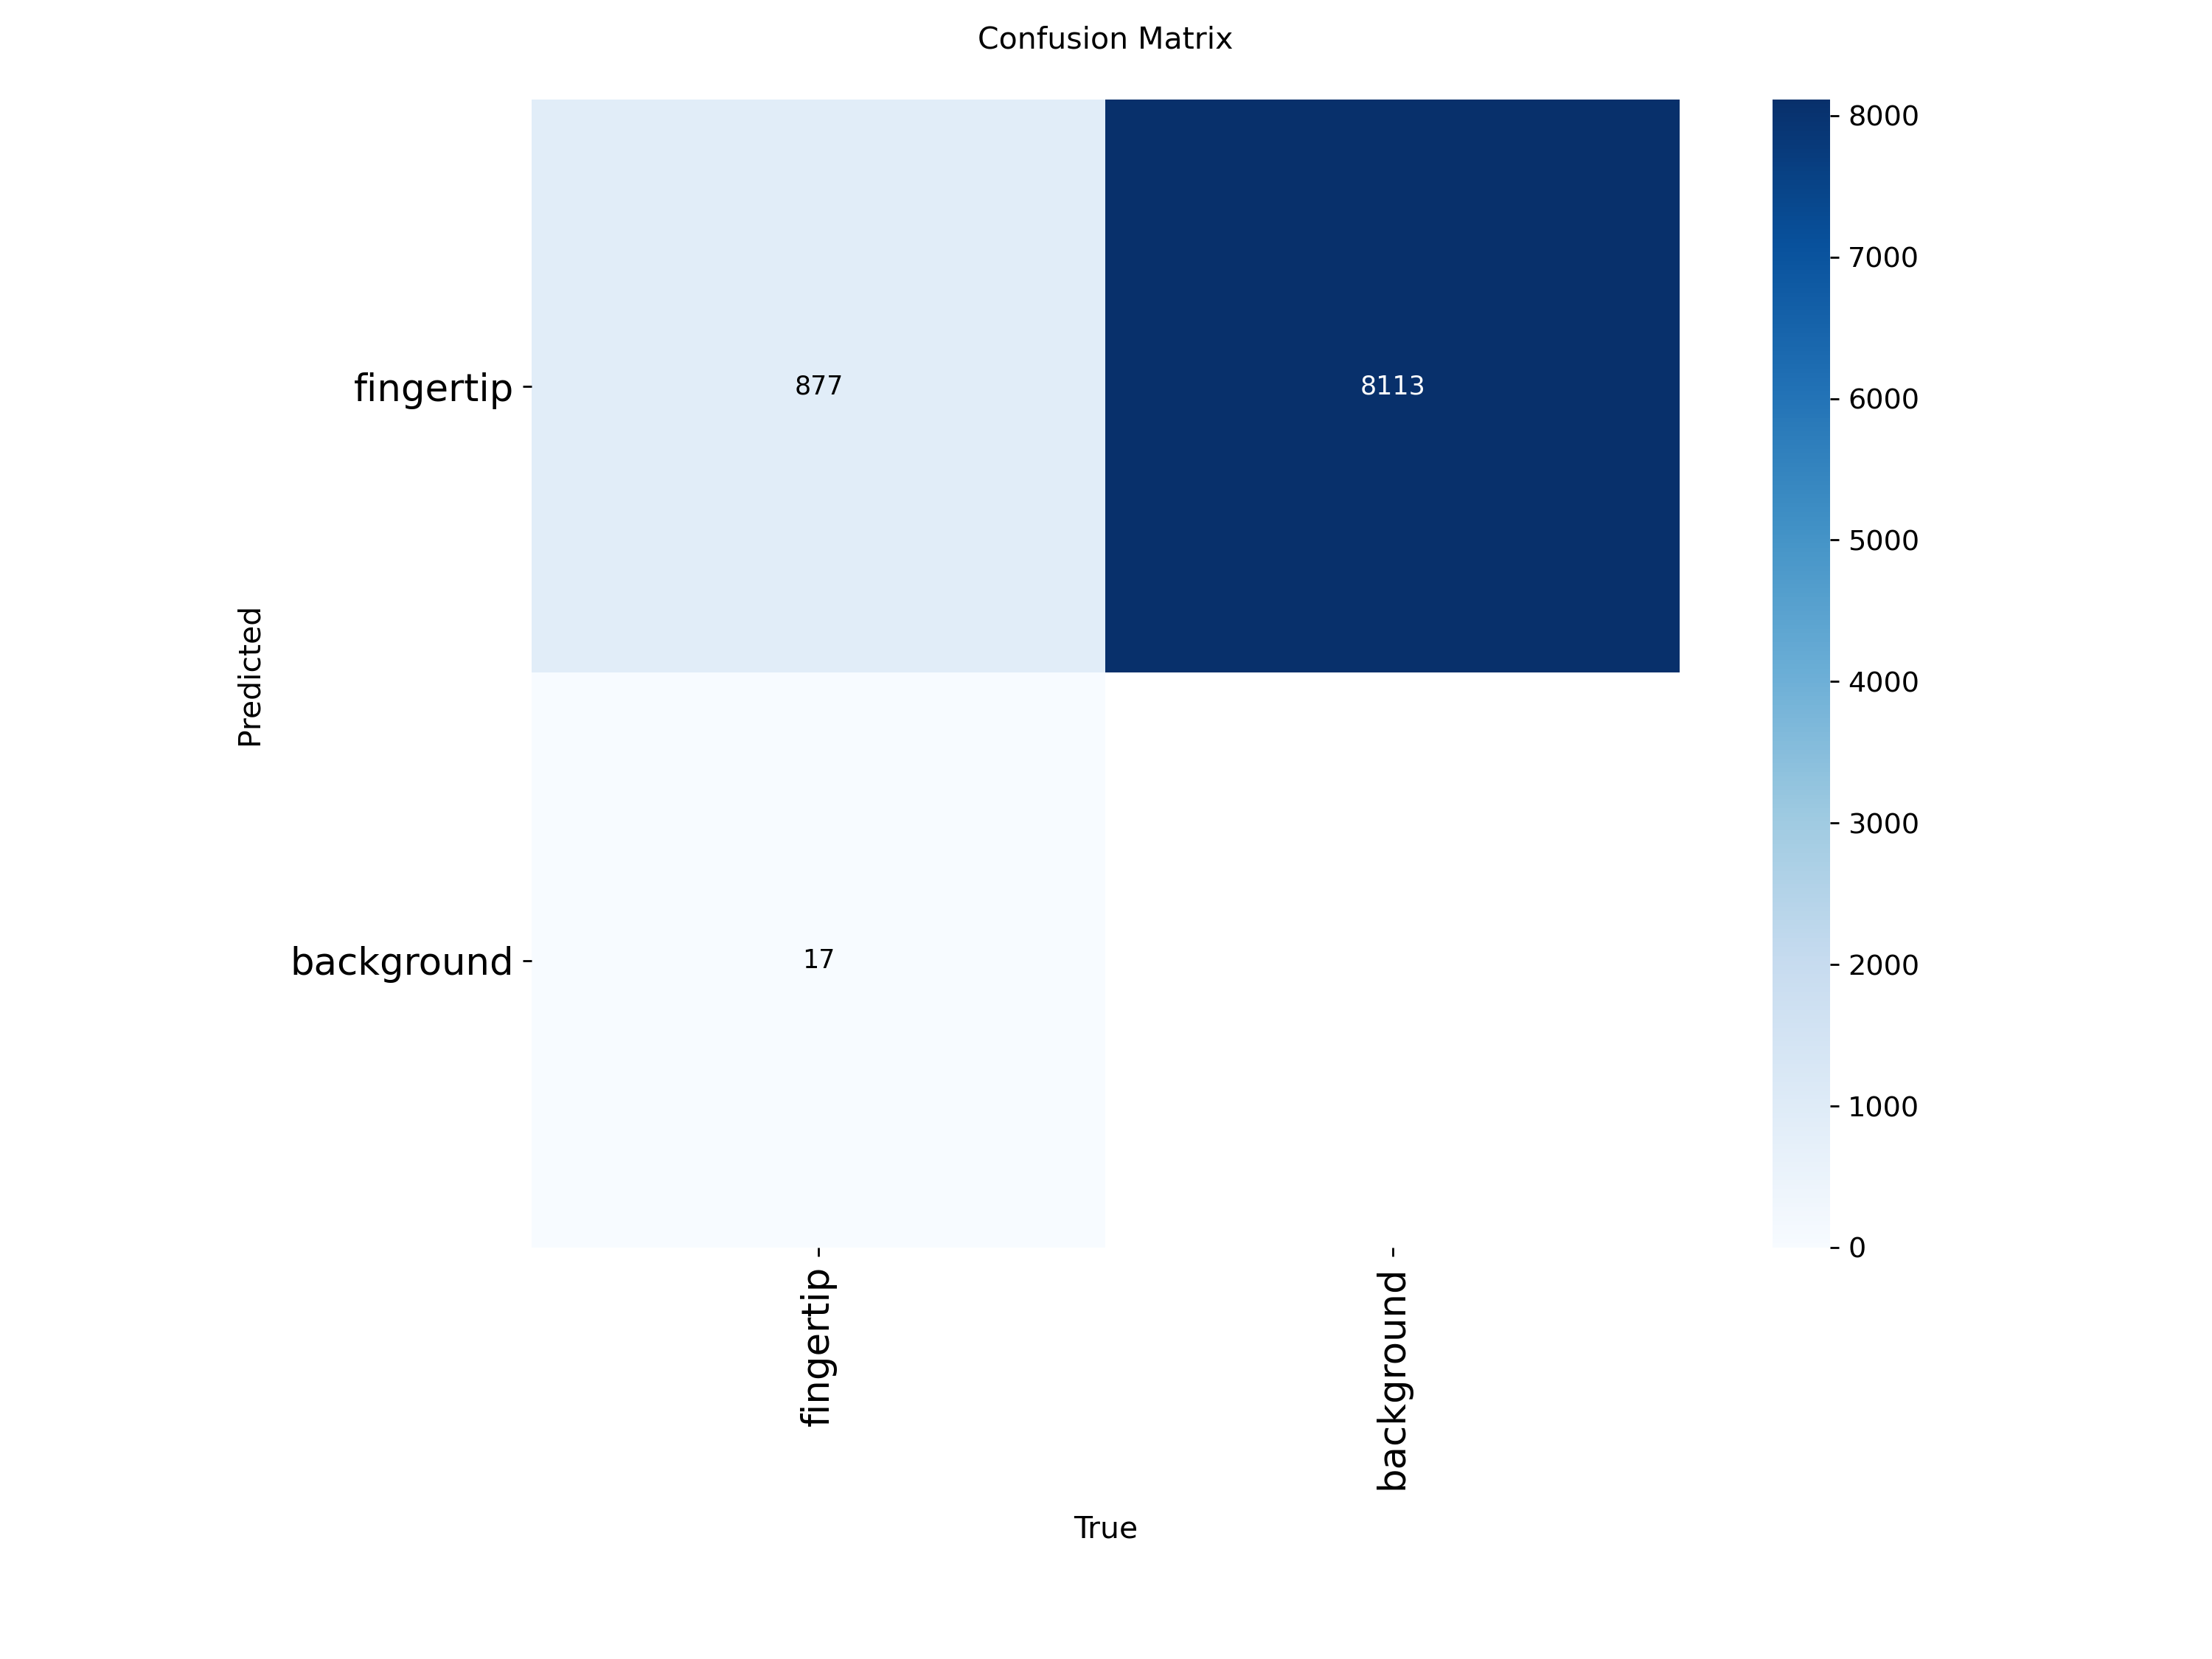

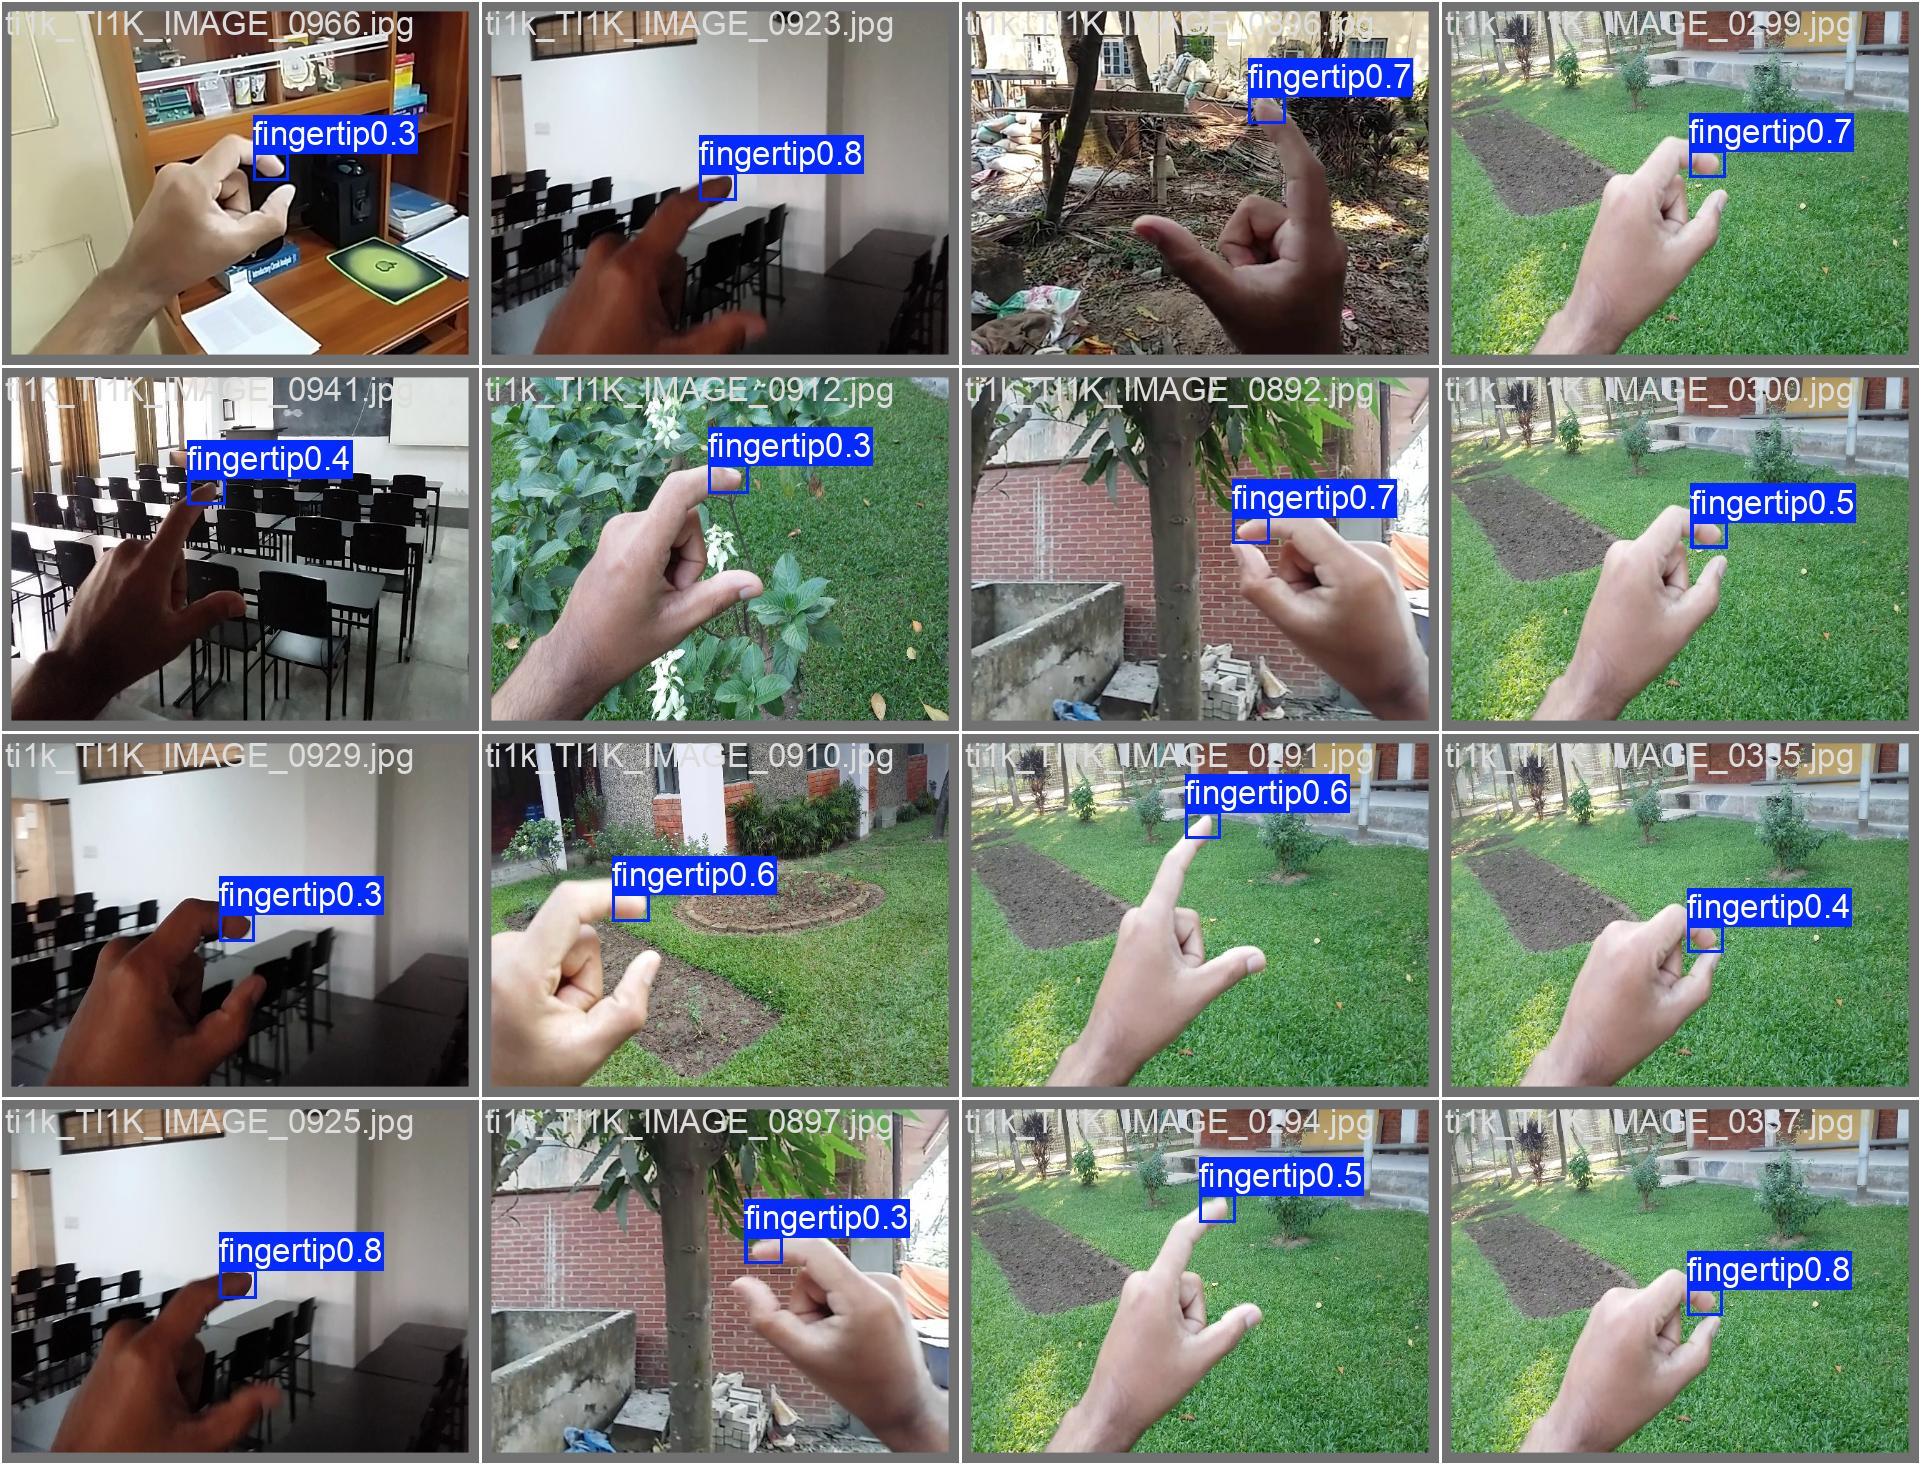

In [13]:
# 6) Validate + show plots
from IPython.display import Image, display
from pathlib import Path
import shutil

best = Path(PROJECT) / NAME / 'weights' / 'best.pt'
print('best:', best, best.exists())

YOLO(str(best)).val(data=str(DATA_YAML), imgsz=IMGSZ)

for plot_name in ('results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg'):
    p = Path(PROJECT) / NAME / plot_name
    if p.exists():
        display(Image(filename=str(p)))

In [14]:
# 7) Copy weights to Drive for download
drive_out = Path('/content/drive/MyDrive/BrailleLens')
drive_out.mkdir(parents=True, exist_ok=True)
dst = drive_out / 'yolo26n_fingertip_best.pt'
shutil.copy2(best, dst)
print('Saved to Drive:', dst)
print('Also download from Colab file browser:', best)

Saved to Drive: /content/drive/MyDrive/BrailleLens/yolo26n_fingertip_best.pt
Also download from Colab file browser: /content/runs/fingertip/yolo26n_tip/weights/best.pt


## After Colab

1. Download `yolo26n_fingertip_best.pt` from Drive.
2. Put it on your PC as `finger_cell_track/weights/yolo26n_fingertip_best.pt`.
3. Next: wire that weight into live tip detection (replace MediaPipe).